### Carga de datos y estadísticas descriptivas

In [0]:
from pyspark.sql.functions import col

# Cargar la tabla limpia desde el catálogo default
df_citas = spark.table("default.citas_pmm_limpio")

# Verificar el número total de registros cargados
print(f"Total de registros para el EDA: {df_citas.count()}")

# Estadísticas descriptivas de variables biométricas y numéricas
columnas_biometricas = ["edad_pac_cita", "peso_kg", "altura_m", "imc", "mins_cit"]
print("\n--- Resumen Estadístico de Variables Biométricas ---")
df_citas.select(columnas_biometricas).summary().display()

# Estadísticas descriptivas de variables financieras
columnas_financieras = ["pago_clie", "pago_aseg", "pago_total"]
print("\n--- Resumen Estadístico de Variables Financieras ---")
df_citas.select(columnas_financieras).summary().display()

Total de registros para el EDA: 10000

--- Resumen Estadístico de Variables Biométricas ---


summary,edad_pac_cita,peso_kg,altura_m,imc,mins_cit
count,10000,10000,10000,10000,10000
mean,41.4262,59.921859999999796,1.5078580000000006,24.21122000000002,37.3245
stddev,26.366157683422486,26.12234717330327,0.31058209536255654,5.8026341576836264,16.8534151883335
min,0,3.5,0.5,13.9,15
25%,18,47.8,1.53,19.3,15
50%,40,65.4,1.62,24.4,30
75%,61,77.7,1.69,28.4,60
max,96,135.3,1.96,45.0,60



--- Resumen Estadístico de Variables Financieras ---


summary,pago_clie,pago_aseg,pago_total
count,10000,10000,10000
mean,19.183780000000013,20.765719999999973,39.9495
stddev,18.62952584568189,19.136854422849076,23.212686889571042
min,0.0,0.0,0.0
25%,6.1,0.0,25.0
50%,14.09,23.57,45.0
75%,25.0,35.95,55.0
max,75.0,67.43,75.0


### Análisis de Distribuciones de Variables Categóricas y Numéricas

In [0]:
# Distribución de citas por Sucursal
print("--- Volumen de Citas por Sucursal ---")
df_citas.groupBy("nom_sucursal").count().orderBy("count", ascending=False).display()

# Distribución de citas por Aseguradora
print("\n--- Volumen de Citas por Aseguradora ---")
df_citas.groupBy("nom_aseguradora").count().orderBy("count", ascending=False).display()

# Top 5 de Especialidades Médicas con mayor demanda
print("\n--- Top 5 Especialidades Médicas ---")
df_citas.groupBy("especialidad_medica").count().orderBy("count", ascending=False).limit(5).display()

--- Volumen de Citas por Sucursal ---


nom_sucursal,count
PMM San Francisco,2976
PMM Costa del Este,2556
PMM El Dorado,1955
PMM Brisas del Golf,1527
PMM Tocumen,986



--- Volumen de Citas por Aseguradora ---


nom_aseguradora,count
Particular / Sin Seguro,2510
PALIG,1623
MAPFRE Panamá,1569
Seguros ASSA,1518
Compañía Internacional de Seguros (IS),1404
Seguros SURA,1376



--- Top 5 Especialidades Médicas ---


especialidad_medica,count
Medicina General,927
Fisioterapia,916
Dermatología,898
Oftalmología,898
Otorrinolaringología,855


### Correlaciones Visuales - Mapa de Calor

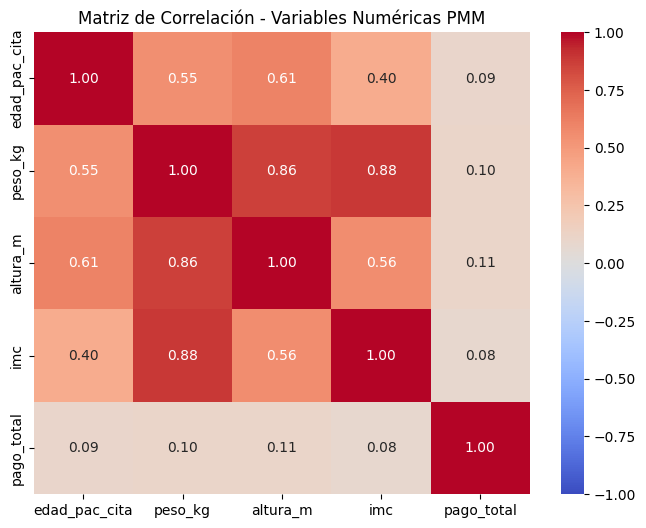

In [0]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar las variables numéricas continuas clave
columnas_num = ["edad_pac_cita", "peso_kg", "altura_m", "imc", "pago_total"]

# Ensamblar las columnas en un vector denso (Requisito de Spark ML)
assembler = VectorAssembler(inputCols=columnas_num, outputCol="features")
df_vector = assembler.transform(df_citas.select(columnas_num))

# Calcular la matriz de correlación de Pearson
matrix = Correlation.corr(df_vector, "features").collect()[0][0]
corr_matrix = matrix.toArray().tolist()

# Convertir a un DataFrame de Pandas para poder usar Seaborn
df_corr = pd.DataFrame(corr_matrix, index=columnas_num, columns=columnas_num)

# Dibujar el mapa de calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación - Variables Numéricas PMM")
plt.show()